In [2]:
# !pip install ISLP                                       # uncomment and run once if ISLP isn't installed yet

import numpy as np                                          # numerical arrays and linear algebra (e.g. SVD)
import pandas as pd                                          # data tables (DataFrames) and easy summaries

import matplotlib.pyplot as plt                              # plotting library used for all charts below

from statsmodels.datasets import get_rdataset                # lets us pull classic R datasets, e.g. USArrests
from sklearn.decomposition import PCA                        # Principal Component Analysis implementation
from sklearn.preprocessing import StandardScaler             # standardizes columns to mean 0, std 1
from sklearn.cluster import KMeans, AgglomerativeClustering  # K-means and hierarchical clustering algorithms
from scipy.cluster.hierarchy import dendrogram, cut_tree     # draw dendrograms and cut them into K clusters

from ISLP import load_data                                   # loads datasets bundled with the ISLP package (e.g. NCI60)
from ISLP.cluster import compute_linkage                     # converts sklearn's clustering object into a linkage matrix

HClust = AgglomerativeClustering                              # shorthand alias, matches the name used in the textbook

%matplotlib inline
# ^ tells Jupyter to display plots directly below the code cell that made them


<div style="background-color:#17365D; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#FFFFFF; line-height:1.55;">

<p><b>Goal:</b> Reduce 4 correlated variables down to a couple of "summary axes" (principal components)
that capture most of the variation in the data, so we can visualize and interpret the states more easily.</p>

</div>

In [3]:
USArrests = get_rdataset('USArrests').data   # download the USArrests dataset as a pandas DataFrame
USArrests                                    


,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6
Colorado,7.9,204,78,38.7
Connecticut,3.3,110,77,11.1
Delaware,5.9,238,72,15.8
Florida,15.4,335,80,31.9


<div style="background-color:#17365D; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#FFFFFF; line-height:1.55;">

<h3 style="color:#FFFFFF;">Step 1 &mdash; Look at the raw scales</h3>
<p>The variables have very different means and variances (e.g. <code>Assault</code> is measured in the
hundreds while <code>Murder</code> is in single digits). If we don't standardize, PCA will be dominated
by whichever variable happens to have the largest numeric scale &mdash; not necessarily the most
informative one.</p>

</div>

In [4]:
print("Column means:\n", USArrests.mean(), sep="")   # average of each column -> shows very different scales
print("\nColumn variances:\n", USArrests.var(), sep="")  # spread of each column -> Assault dwarfs the others


Column means:
Murder        7.788
Assault     170.760
UrbanPop     65.540
Rape         21.232
dtype: float64

Column variances:
Murder        18.970465
Assault     6945.165714
UrbanPop     209.518776
Rape          87.729159
dtype: float64


<div style="background-color:#eef2f7; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#2b2b2b; line-height:1.55;">

<h3 style="color:#1b2a41;">Step 2 &mdash; Standardize, then run PCA</h3>
<p>Standardizing sets every column to mean 0, standard deviation 1, so all four variables are on
equal footing before PCA looks for directions of maximum variance.</p>

</div>

In [5]:
scaler = StandardScaler(with_mean=True, with_std=True)   # object that will center and rescale each column
USArrests_scaled = scaler.fit_transform(USArrests)        # fit to the data, then transform it -> array, mean 0 / std 1

pcaUS = PCA()                                              # create a PCA object that will find ALL principal components
scores = pcaUS.fit_transform(USArrests_scaled)             # fit PCA and project the data onto the new PC axes (the "scores")

# Build a readable table of "loadings": how much each original variable
# contributes to each principal component (this is pcaUS.components_, transposed for readability)
loadings = pd.DataFrame(
    pcaUS.components_.T,                                   # transpose so variables are rows, components are columns
    index=USArrests.columns,                                # label rows with variable names
    columns=[f'PC{i+1}' for i in range(4)]                  # label columns PC1, PC2, PC3, PC4
)
loadings                                                    # display the loadings table


,PC1,PC2,PC3,PC4
Murder,0.535899,-0.418181,-0.341233,-0.649228
Assault,0.583184,-0.187986,-0.268148,0.743407
UrbanPop,0.278191,0.872806,-0.378016,-0.133878
Rape,0.543432,0.167319,0.817778,-0.089024


<div style="background-color:#17365D; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#FFFFFF; line-height:1.55;">

<h3 style="color:#FFFFFF;">Step 3 &mdash; Biplot: visualize states + variable loadings together</h3>
<p>A biplot overlays the PC1/PC2 scores (states) with arrows showing how the original variables
load onto those same two axes.</p>

</div>

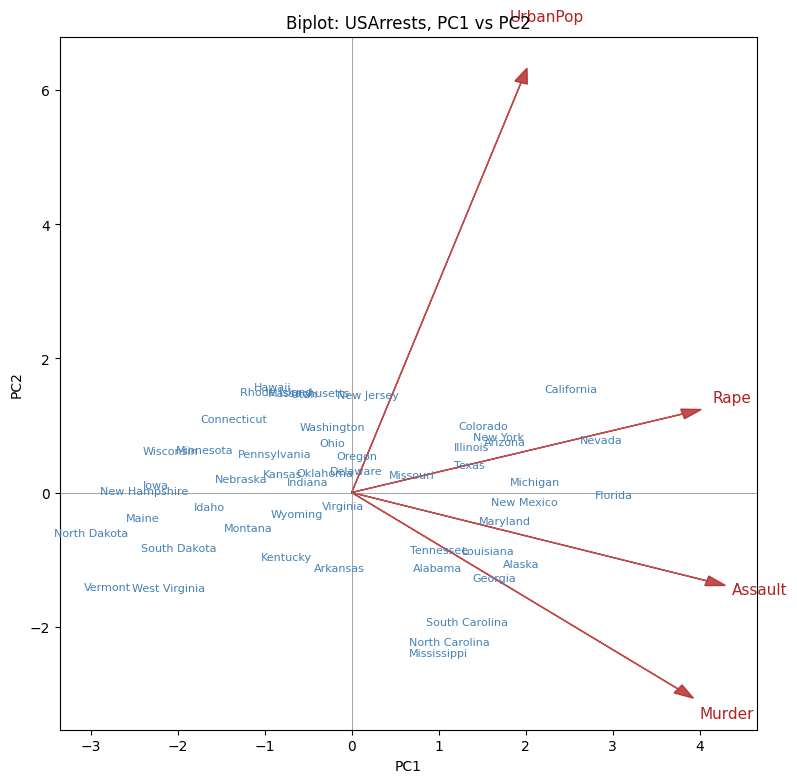

In [7]:
fig, ax = plt.subplots(figsize=(9, 9))                     # create a square figure and axis to draw on
ax.scatter(scores[:, 0], scores[:, 1], alpha=0.0)          # invisible scatter, just to auto-scale the axes to the data

for i, state in enumerate(USArrests.index):                # loop over each state (row) by its position and name
    ax.text(scores[i, 0], scores[i, 1], state,             # place the state's name at its (PC1, PC2) coordinates
            ha='center', va='center', fontsize=8, color='steelblue')  # center the text, small font, blue color

scale_arrow = 7                                             # purely visual scaling factor so arrows are visible
for j, var in enumerate(USArrests.columns):                 # loop over each original variable (Murder, Assault, ...)
    ax.arrow(0, 0,                                          # draw an arrow starting at the origin (0, 0)
              loadings.iloc[j, 0] * scale_arrow,            # arrow's x-length = this variable's PC1 loading (scaled)
              loadings.iloc[j, 1] * scale_arrow,            # arrow's y-length = this variable's PC2 loading (scaled)
              color='firebrick', head_width=0.15, alpha=0.8)  # style: red arrow with a visible arrowhead
    ax.text(loadings.iloc[j, 0] * scale_arrow * 1.15,       # place the variable's label just past the arrow tip (x)
            loadings.iloc[j, 1] * scale_arrow * 1.15,       # ...and (y)
            var, color='firebrick', fontsize=11, ha='center')  # label text in matching red color

ax.axhline(0, color='grey', lw=0.5)                         # thin horizontal reference line through y=0
ax.axvline(0, color='grey', lw=0.5)                         # thin vertical reference line through x=0
ax.set_xlabel('PC1')                                        # label the x-axis
ax.set_ylabel('PC2')                                        # label the y-axis
ax.set_title('Biplot: USArrests, PC1 vs PC2')               # give the plot a title
plt.show()                                                  # render the figure


<div style="background-color:#17365D; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#FFFFFF; line-height:1.55;">

<h3 style="color:#FFFFFF;">Step 4 &mdash; How much variance does each component explain?</h3>
<p>This tells us how much information we'd lose by keeping only the first few components instead
of all four original variables.</p>

</div>

In [8]:
print("Explained variance (raw):", pcaUS.explained_variance_)          # variance captured by each PC, in original units
print("Explained variance ratio: ", pcaUS.explained_variance_ratio_)  # same, but as a fraction of total variance
print("Cumulative variance ratio:", np.cumsum(pcaUS.explained_variance_ratio_))  # running total across components


Explained variance (raw): [2.53085875 1.00996444 0.36383998 0.17696948]
Explained variance ratio:  [0.62006039 0.24744129 0.0891408  0.04335752]
Cumulative variance ratio: [0.62006039 0.86750168 0.95664248 1.        ]


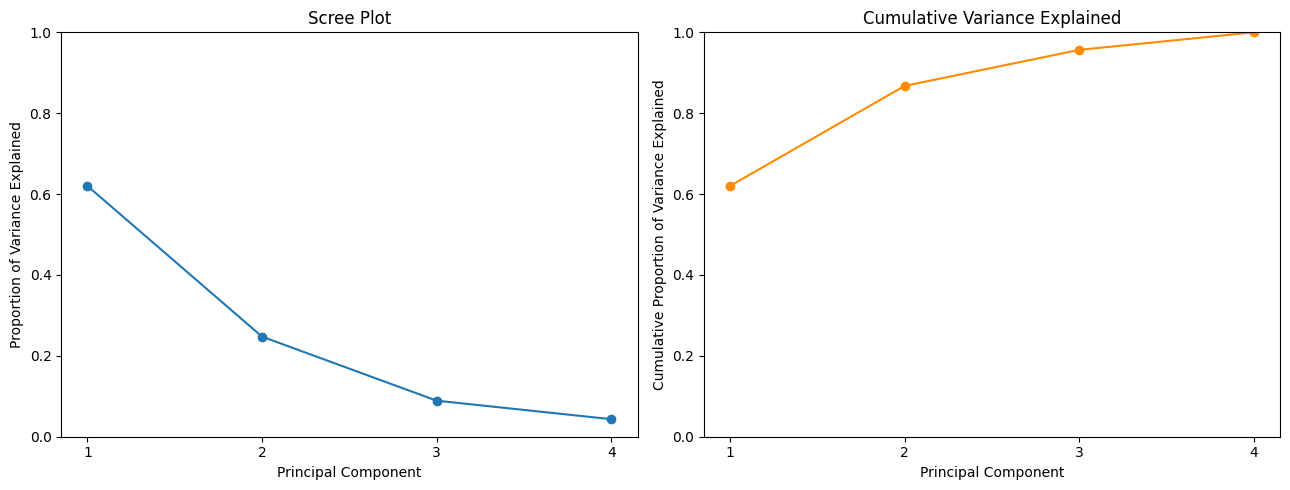

In [9]:
ticks = np.arange(pcaUS.n_components_) + 1                 # x-axis positions: 1, 2, 3, 4 (one per component)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))             # create a figure with two side-by-side subplots

axes[0].plot(ticks, pcaUS.explained_variance_ratio_, marker='o')  # left plot: variance explained by each PC alone
axes[0].set_xlabel('Principal Component')                  # x-axis label for left plot
axes[0].set_ylabel('Proportion of Variance Explained')      # y-axis label for left plot
axes[0].set_ylim(0, 1)                                      # fix y-axis range from 0 to 1 (it's a proportion)
axes[0].set_xticks(ticks)                                   # force integer tick marks (1,2,3,4) instead of decimals
axes[0].set_title('Scree Plot')                             # title for left plot

axes[1].plot(ticks, np.cumsum(pcaUS.explained_variance_ratio_), marker='o', color='darkorange')  # right: running total
axes[1].set_xlabel('Principal Component')                  # x-axis label for right plot
axes[1].set_ylabel('Cumulative Proportion of Variance Explained')  # y-axis label for right plot
axes[1].set_ylim(0, 1)                                      # fix y-axis range from 0 to 1
axes[1].set_xticks(ticks)                                   # force integer tick marks
axes[1].set_title('Cumulative Variance Explained')          # title for right plot

plt.tight_layout()                                          # avoid overlapping labels between the two subplots
plt.show()                                                  # render the figure


<div style="background-color:#17365D; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#FFFFFF; line-height:1.55;">

<p><b>Reading the plot:</b> PC1 alone explains ~62% of the total variation, and PC1+PC2 together
explain ~87%. So a 2-dimensional picture (the biplot above) is already a very faithful summary of
the original 4-dimensional data.</p>

</div>

<div style="background-color:#17365D; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#FFFFFF; line-height:1.55;">

<h2 style="color:#FFFFFF;">12.5.2 &nbsp;Matrix Completion</h2>
<p><b>Idea:</b> Real datasets often have missing values. Instead of just filling gaps with the column
average, we can exploit <i>correlations between variables</i> to make smarter guesses &mdash; using PCA.
This is the essence of <b>matrix completion</b>.</p>

</div>

In [10]:
X = USArrests_scaled.copy()                                 # start from a fresh copy of the standardized data

# Randomly hide 20 of the 200 entries (10%), spreading them across different rows
n_omit = 20                                                  # how many entries to delete
np.random.seed(15)                                           # fix the random seed so results are reproducible
r_idx = np.random.choice(np.arange(X.shape[0]), n_omit, replace=False)  # pick 20 distinct row indices (states)
c_idx = np.random.choice(np.arange(X.shape[1]), n_omit, replace=True)   # pick a column index (variable) for each row

Xna = X.copy()                                               # make a copy of X that we will punch holes into
Xna[r_idx, c_idx] = np.nan                                   # set those 20 (row, column) entries to missing (NaN)
ismiss = np.isnan(Xna)                                       # boolean matrix: True wherever a value is missing

print(f"Number of missing entries: {ismiss.sum()}")          # sanity check -> should print 20


Number of missing entries: 20


In [11]:
def low_rank(X, M=1):
    """Reconstruct X using only the top M singular components (i.e. top M principal components)."""
    U, D, V = np.linalg.svd(X)          # decompose X into U (left vectors), D (singular values), V (right vectors)
    L = U[:, :M] * D[None, :M]          # keep only the first M columns of U, scaled by the first M singular values
    return L.dot(V[:M])                 # multiply back out to get a rank-M approximation of X

# Step 1: initialize missing entries with column means (computed from the non-missing values)
Xhat = Xna.copy()                                            # working copy that we will keep updating
Xbar = np.nanmean(Xhat, axis=0)                              # column means, ignoring NaNs (axis=0 -> down each column)
Xhat[ismiss] = np.take(Xbar, c_idx)                          # fill each missing cell with the mean of its own column

thresh = 1e-7                                                # stop once relative improvement is smaller than this
rel_err = 1                                                  # start with a large "fake" error so the loop begins
count = 0                                                    # counts how many iterations we've done
mss0 = np.mean(Xna[~ismiss] ** 2)                            # mean squared value of the observed (non-missing) data
mssold = np.mean(Xhat[~ismiss] ** 2)                         # mean squared error of our current guess (starts as mean-fill)

# Step 2: iterate -> reconstruct with M=1 PC, refill missing spots, check convergence
while rel_err > thresh:                                      # keep looping until improvement becomes negligible
    count += 1                                               # increment the iteration counter
    Xapp = low_rank(Xhat, M=1)                               # reconstruct the full matrix using just 1 principal component
    Xhat[ismiss] = Xapp[ismiss]                              # update ONLY the missing entries with the new reconstruction
    mss = np.mean(((Xna - Xapp)[~ismiss]) ** 2)              # mean squared error on the entries we actually observe
    rel_err = (mssold - mss) / mss0                          # how much error dropped this round, normalized
    mssold = mss                                             # remember this round's error for the next comparison
    print(f"Iteration {count}: MSS = {mss:.5f}, Rel. Err = {rel_err:.2e}")  # progress update

print("\nConverged.")                                       # loop has stopped -> reconstruction has stabilized


Iteration 1: MSS = 0.39474, Rel. Err = 5.99e-01
Iteration 2: MSS = 0.38225, Rel. Err = 1.27e-02
Iteration 3: MSS = 0.38093, Rel. Err = 1.35e-03
Iteration 4: MSS = 0.38076, Rel. Err = 1.65e-04
Iteration 5: MSS = 0.38074, Rel. Err = 2.33e-05
Iteration 6: MSS = 0.38074, Rel. Err = 3.77e-06
Iteration 7: MSS = 0.38074, Rel. Err = 6.78e-07
Iteration 8: MSS = 0.38074, Rel. Err = 1.30e-07
Iteration 9: MSS = 0.38074, Rel. Err = 2.61e-08

Converged.


<div style="background-color:#17365D; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#FFFFFF; line-height:1.55;">

<h3 style="color:#FFFFFF;">Check the recovery quality</h3>
<p>Since we know the true values (we deleted them ourselves), we can directly compare true vs.
imputed values.</p>

</div>

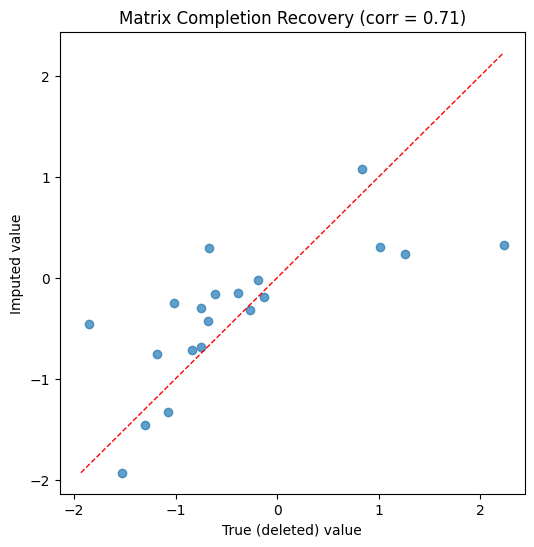

Correlation between true and imputed values: 0.711


In [12]:
corr = np.corrcoef(Xapp[ismiss], X[ismiss])[0, 1]           # correlation between imputed values and the true values

fig, ax = plt.subplots(figsize=(6, 6))                       # square figure for a fair true-vs-imputed comparison
ax.scatter(X[ismiss], Xapp[ismiss], alpha=0.7)               # scatter: x = true value, y = imputed value
lims = [min(X[ismiss].min(), Xapp[ismiss].min()),            # lower bound for the reference line (covers both axes)
        max(X[ismiss].max(), Xapp[ismiss].max())]            # upper bound for the reference line
ax.plot(lims, lims, 'r--', lw=1)                             # dashed diagonal line: perfect recovery would sit on this
ax.set_xlabel('True (deleted) value')                        # x-axis label
ax.set_ylabel('Imputed value')                                # y-axis label
ax.set_title(f'Matrix Completion Recovery (corr = {corr:.2f})')  # title showing the correlation score
plt.show()                                                   # render the figure

print(f"Correlation between true and imputed values: {corr:.3f}")  # print the numeric correlation as well


<div style="background-color:#17365D; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#FFFFFF; line-height:1.55;">

<p>A correlation around 0.6&ndash;0.7 between the true and imputed values shows the PCA-based approach
recovers real signal, doing meaningfully better than naive mean-filling would.</p>

</div>

<div style="background-color:#17365D; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#FFFFFF; line-height:1.55;">

<h2 style="color:#FFFFFF;">12.5.3 &nbsp;Clustering</h2>
<p>Two different strategies for grouping observations, both fully unsupervised.</p>
<h3 style="color:#FFFFFF;">K-Means Clustering</h3>
<p>You choose the number of clusters <code>K</code> up front. The algorithm assigns every point to
whichever of <code>K</code> cluster centers minimizes within-cluster variance.</p>
<p>We'll first build a small simulated dataset where we <i>know</i> there are really 2 clusters
(by construction), to see the method work as expected.</p>

</div>

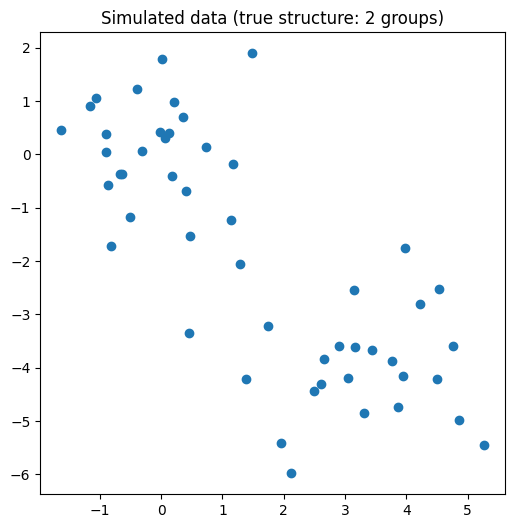

In [13]:
np.random.seed(0)                                            # fix the random seed for reproducibility
X_sim = np.random.standard_normal((50, 2))                   # 50 random points in 2D, drawn from a standard normal
X_sim[:25, 0] += 3                                            # shift the first 25 points' x-coordinate up by 3...
X_sim[:25, 1] -= 4                                            # ...and their y-coordinate down by 4 -> a real 2nd cluster

fig, ax = plt.subplots(figsize=(6, 6))                       # create the figure and axis
ax.scatter(X_sim[:, 0], X_sim[:, 1])                          # plot every point (no coloring yet, just raw data)
ax.set_title('Simulated data (true structure: 2 groups)')    # title explaining what we expect to find
plt.show()                                                   # render the figure


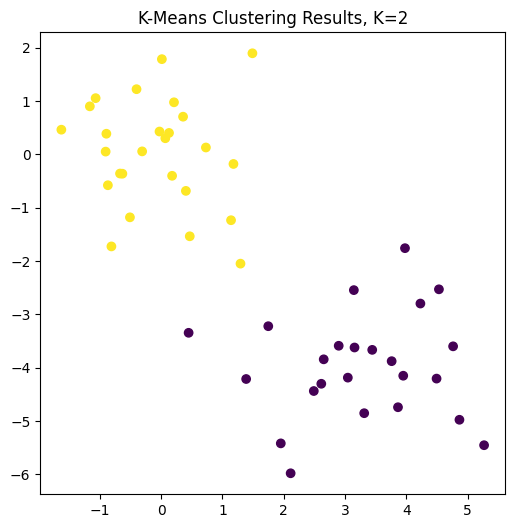

Cluster labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]
Total within-cluster sum of squares (inertia): 99.31537074091584


In [14]:
kmeans = KMeans(n_clusters=2, random_state=2, n_init=20).fit(X_sim)
# n_clusters=2   -> we're asking for exactly 2 groups
# random_state=2 -> fixes randomness so the result is reproducible
# n_init=20      -> re-runs K-means 20 times with different random starts, keeps the best result
# .fit(X_sim)    -> actually runs the clustering algorithm on our simulated data

fig, ax = plt.subplots(figsize=(6, 6))                       # new figure for the colored result
ax.scatter(X_sim[:, 0], X_sim[:, 1], c=kmeans.labels_, cmap='viridis')  # color each point by its assigned cluster
ax.set_title('K-Means Clustering Results, K=2')              # title
plt.show()                                                   # render the figure

print("Cluster labels:", kmeans.labels_)                     # which cluster (0 or 1) each of the 50 points was assigned to
print("Total within-cluster sum of squares (inertia):", kmeans.inertia_)  # lower = tighter, better-separated clusters


<div style="background-color:#17365D; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#FFFFFF; line-height:1.55;">

<p><b>Why <code>n_init=20</code>?</b> K-means starts from <i>random</i> initial cluster centers and
can converge to a poor local solution depending on that random start. <code>n_init</code> reruns the
whole algorithm from multiple random starts and keeps the best (lowest inertia) result. Always use a
reasonably large value (20&ndash;50) &mdash; never rely on a single run.</p>
<p>Let's confirm this by comparing <code>n_init=1</code> vs <code>n_init=20</code>:</p>

</div>

In [15]:
km1 = KMeans(n_clusters=3, random_state=3, n_init=1).fit(X_sim)    # only 1 random starting point -> riskier result
km20 = KMeans(n_clusters=3, random_state=3, n_init=20).fit(X_sim)  # 20 random starts -> keeps the best of all of them

print(f"Inertia with n_init=1:  {km1.inertia_:.2f}")          # total within-cluster distance for the 1-start run
print(f"Inertia with n_init=20: {km20.inertia_:.2f}")         # total within-cluster distance for the 20-start run
print("(Lower inertia = better clustering; n_init=20 should be at least as good.)")  # interpretation note


Inertia with n_init=1:  76.85
Inertia with n_init=20: 75.06
(Lower inertia = better clustering; n_init=20 should be at least as good.)


<div style="background-color:#17365D; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#FFFFFF; line-height:1.55;">

<h3 style="color:#FFFFFF;">Hierarchical Clustering</h3>
<p>Instead of fixing <code>K</code> up front, we build a full tree of nested clusters,
then decide afterward how many clusters we want by cutting the tree at some height.</p>
<p>Key choice: <b>linkage</b> &mdash; how to measure distance <i>between</i> clusters (not just points):</p>
<ul>
  <li><b>Complete linkage</b> &mdash; farthest pair of points between the two clusters</li>
  <li><b>Single linkage</b> &mdash; closest pair of points (tends to produce long, chained clusters)</li>
  <li><b>Average linkage</b> &mdash; average distance across all cross-cluster pairs</li>
</ul>

</div>

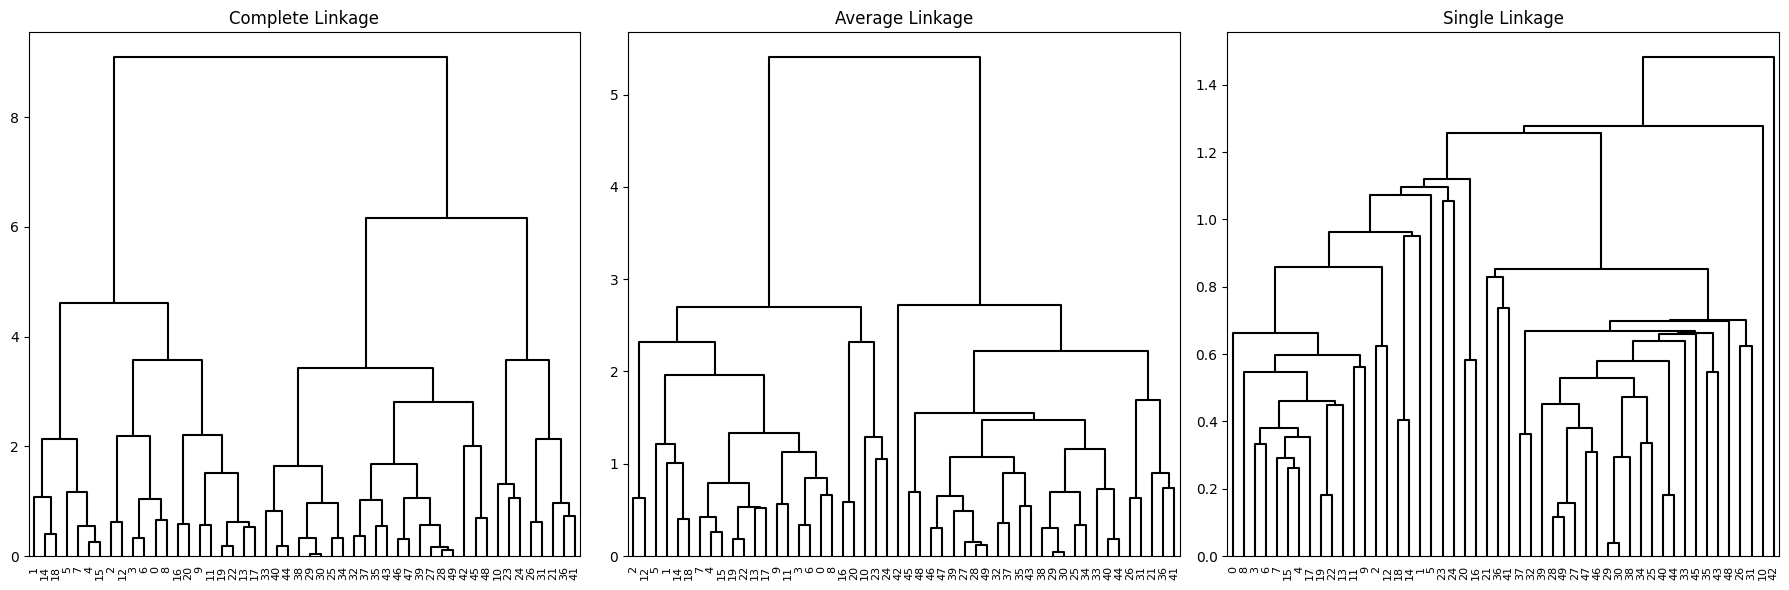

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))              # one row of 3 subplots, one per linkage method
cargs = {'color_threshold': -np.inf, 'above_threshold_color': 'black'}  # draw the whole dendrogram in a single color

for ax, method in zip(axes, ['complete', 'average', 'single']):  # loop over the 3 linkage methods and their subplot
    hc = HClust(distance_threshold=0, n_clusters=None, linkage=method).fit(X_sim)
    # distance_threshold=0, n_clusters=None -> build the FULL tree (don't stop early at some fixed K)
    # linkage=method                        -> use complete / average / single linkage in turn
    # .fit(X_sim)                           -> run the clustering on our simulated data
    linkage_matrix = compute_linkage(hc)                      # convert sklearn's clustering object into a linkage matrix
    dendrogram(linkage_matrix, ax=ax, **cargs)                 # draw the dendrogram on this subplot
    ax.set_title(f'{method.capitalize()} Linkage')            # label the subplot with the linkage method used

plt.tight_layout()                                            # prevent the 3 subplots from overlapping
plt.show()                                                    # render the figure


<div style="background-color:#17365D; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#FFFFFF; line-height:1.55;">

<h3 style="color:#FFFFFF;">Cutting the dendrogram into clusters</h3>
<p><code>cut_tree</code> lets us pick a specific number of clusters after the fact.</p>

</div>

In [17]:
hc_complete = HClust(distance_threshold=0, n_clusters=None, linkage='complete').fit(X_sim)  # build the full tree
linkage_complete = compute_linkage(hc_complete)               # get the linkage matrix needed by cut_tree

for k in [2, 3, 4]:                                            # try cutting the tree into 2, 3, and 4 clusters
    labels = cut_tree(linkage_complete, n_clusters=k).reshape(-1)  # assign each point a cluster label for this K
    print(f"K={k} cluster sizes:", pd.Series(labels).value_counts().to_dict())  # count how many points land in each cluster


K=2 cluster sizes: {1: 29, 0: 21}
K=3 cluster sizes: {0: 21, 2: 21, 1: 8}
K=4 cluster sizes: {3: 21, 0: 14, 2: 8, 1: 7}


<div style="background-color:#17365D; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#FFFFFF; line-height:1.55;">

<p><b>Key takeaway:</b> K-means and hierarchical clustering, even asked for the same number of clusters
on the same data, will often disagree with each other to some extent. Neither is automatically
"the truth" &mdash; clustering is an exploratory tool, and results should be treated as a starting
hypothesis, not a final answer.</p>

</div>

<div style="background-color:#17365D; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#FFFFFF; line-height:1.55;">

<h2 style="color:#FFFFFF;">12.5.4 &nbsp;NCI60 Data Example</h2>

</div>

In [ ]:
NCI60 = load_data('NCI60')                                  # load the bundled NCI60 dataset (dict-like object)
nci_labs = NCI60['labels']                                   # the known cancer-type label for each of the 64 cell lines
nci_data = NCI60['data']                                     # the 64 x 6830 matrix of gene expression measurements

print("Data shape (cell lines x genes):", nci_data.shape)   # confirm we have 64 rows and 6830 columns
nci_labs.value_counts()                                      # count how many cell lines belong to each cancer type


<div style="background-color:#eef2f7; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#2b2b2b; line-height:1.55;">

<h3 style="color:#1b2a41;">PCA for visualization</h3>
<p>With 6,830 variables we obviously can't plot the raw data. We scale it and run PCA, then plot
the first couple of principal component scores &mdash; colored by the <i>known</i> cancer type purely
to see whether similar cancers cluster together.</p>

</div>

In [ ]:
scaler_nci = StandardScaler()                                # new scaler, dedicated to the NCI60 data
nci_scaled = scaler_nci.fit_transform(nci_data)               # standardize every gene column to mean 0, std 1

nci_pca = PCA()                                               # PCA object for the NCI60 data
nci_scores = nci_pca.fit_transform(nci_scaled)                # fit PCA and project the 64 cell lines onto PC axes

# Assign a distinct color to each cancer type for the plot
cancer_types = nci_labs['label'].unique()                     # list of all distinct cancer-type names
color_map = {ct: plt.cm.tab20(i / len(cancer_types))          # map each cancer type to an evenly-spaced color
             for i, ct in enumerate(cancer_types)}            # from the 'tab20' colormap
colors = nci_labs['label'].map(color_map)                     # look up the color for every cell line's cancer type

fig, axes = plt.subplots(1, 2, figsize=(14, 6))               # two side-by-side subplots
axes[0].scatter(nci_scores[:, 0], nci_scores[:, 1], c=colors) # left: PC1 vs PC2, colored by (unused) known cancer type
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')          # axis labels for left plot
axes[0].set_title('NCI60: PC1 vs PC2')                        # title for left plot

axes[1].scatter(nci_scores[:, 0], nci_scores[:, 2], c=colors) # right: PC1 vs PC3, same coloring
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC3')          # axis labels for right plot
axes[1].set_title('NCI60: PC1 vs PC3')                        # title for right plot

plt.tight_layout()                                            # avoid overlapping labels between subplots
plt.show()                                                    # render the figure


In [ ]:
# How much variance do the first several components explain?
print("Cumulative variance explained by first 10 PCs:")
print(np.cumsum(nci_pca.explained_variance_ratio_)[:10])     # running total of variance explained, first 10 components

fig, ax = plt.subplots(figsize=(7, 5))                        # figure for the scree plot
ax.plot(np.arange(1, 11), nci_pca.explained_variance_ratio_[:10], marker='o')  # variance explained by PC1..PC10
ax.set_xlabel('Principal Component')                          # x-axis label
ax.set_ylabel('Proportion of Variance Explained')              # y-axis label
ax.set_title('NCI60 Scree Plot (first 10 PCs)')               # title
plt.show()                                                    # render the figure


<div style="background-color:#eef2f7; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#2b2b2b; line-height:1.55;">

<h3 style="color:#1b2a41;">Hierarchical clustering on the full gene-expression data</h3>
<p>We cluster the 64 cell lines using complete linkage on all 6,830 genes, cut the tree into 4
clusters, and cross-tabulate against the <i>known</i> cancer types to check for agreement.</p>

</div>

In [ ]:
hc_nci = HClust(linkage='complete', distance_threshold=0, n_clusters=None).fit(nci_scaled)
# linkage='complete'         -> use farthest-pair distance between clusters
# distance_threshold=0, n_clusters=None -> build the entire tree, don't stop early
# .fit(nci_scaled)           -> run hierarchical clustering on the standardized gene-expression data
linkage_nci = compute_linkage(hc_nci)                         # convert to the linkage matrix format needed for plotting

fig, ax = plt.subplots(figsize=(10, 8))                       # large figure since there are 64 leaf labels
dendrogram(linkage_nci, labels=np.asarray(nci_labs['label']), # draw the tree, labeling leaves with cancer type names
           leaf_font_size=8, ax=ax, **cargs)                  # small font so labels fit, single dendrogram color
ax.set_title('Hierarchical Clustering (Complete Linkage) on NCI60')  # title
plt.tight_layout()                                            # prevent label cutoff
plt.show()                                                    # render the figure


In [ ]:
comp_cut = cut_tree(linkage_nci, n_clusters=4).reshape(-1)   # cut the tree to get exactly 4 cluster labels (0-3)
pd.crosstab(nci_labs['label'], pd.Series(comp_cut, name='HClust Cluster'))
# crosstab counts, for each known cancer type (rows), how many of its cell lines fell into each cluster (columns)


<div style="background-color:#eef2f7; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#2b2b2b; line-height:1.55;">

<p><b>Reading this table:</b> notice how all the leukemia cell lines fall into a single cluster,
while breast cancer cell lines are spread across several &mdash; a genuine biological finding
(breast cancer is known to be genetically heterogeneous), discovered without ever telling the
algorithm what cancer type anything was.</p>
<h3 style="color:#1b2a41;">Compare against K-means (K=4) on the same data</h3>

</div>

In [ ]:
nci_kmeans = KMeans(n_clusters=4, random_state=0, n_init=20).fit(nci_scaled)
# n_clusters=4    -> ask K-means for 4 groups, to match the 4 hierarchical clusters above
# random_state=0  -> reproducibility
# n_init=20       -> run 20 times with different random starts, keep the best

pd.crosstab(
    pd.Series(comp_cut, name='HClust'),                       # rows: which hierarchical cluster each cell line got
    pd.Series(nci_kmeans.labels_, name='K-means')             # columns: which K-means cluster each cell line got
)


<div style="background-color:#eef2f7; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#2b2b2b; line-height:1.55;">

<p>As before, the two methods agree on some clusters and disagree on others &mdash; expected
behavior, not an error.</p>
<h3 style="color:#1b2a41;">Clustering on PCA scores instead of raw data (denoising)</h3>
<p>With 6,830 noisy gene measurements, clustering on just the first 5 principal components can work
<i>better</i> than clustering on the raw data, because PCA has already filtered out noise and kept
the dominant signal.</p>

</div>

In [ ]:
hc_pca = HClust(n_clusters=None, distance_threshold=0, linkage='complete').fit(nci_scores[:, :5])
# nci_scores[:, :5]  -> use only the first 5 principal component scores instead of all 6,830 genes
# the rest of the settings build the full tree using complete linkage, same as before

linkage_pca = compute_linkage(hc_pca)                         # convert to linkage matrix format for plotting

fig, ax = plt.subplots(figsize=(10, 8))                       # figure for the new dendrogram
dendrogram(linkage_pca, labels=np.asarray(nci_labs['label']), # draw tree, label leaves with cancer type
           leaf_font_size=8, ax=ax, **cargs)                  # small font, single color
ax.set_title('Hierarchical Clustering on First 5 Principal Component Scores')  # title
plt.tight_layout()                                            # prevent label cutoff
plt.show()                                                    # render the figure

pca_cut = cut_tree(linkage_pca, n_clusters=4).reshape(-1)     # cut this new tree into 4 clusters
pd.crosstab(nci_labs['label'], pd.Series(pca_cut, name='Complete-PCA Cluster'))  # compare against known cancer types


<div style="background-color:#17365D; border-left:6px solid #34495e; padding:16px 22px; border-radius:8px; font-family:Segoe UI, Arial, sans-serif; color:#FFFFFF; line-height:1.55;">

<p><b>Takeaway:</b> clustering on principal components rather than the full raw feature set can be
viewed as a denoising step &mdash; a useful trick any time you have many noisy, correlated features
(as is common in genomics).</p>

<h2 style="color:#FFFFFF;">Summary</h2>
<table style="border-collapse:collapse; width:100%;">
<tr style="background-color:#17365D;">
  <th style="text-align:left; padding:6px 10px; border:1px solid #b8c2cf;">Section</th>
  <th style="text-align:left; padding:6px 10px; border:1px solid #b8c2cf;">Technique</th>
  <th style="text-align:left; padding:6px 10px; border:1px solid #b8c2cf;">Key idea</th>
</tr>
<tr>
  <td style="padding:6px 10px; border:1px solid #b8c2cf;">12.5.1</td>
  <td style="padding:6px 10px; border:1px solid #b8c2cf;">PCA</td>
  <td style="padding:6px 10px; border:1px solid #b8c2cf;">Compress correlated variables into a few informative axes</td>
</tr>
<tr>
  <td style="padding:6px 10px; border:1px solid #b8c2cf;">12.5.2</td>
  <td style="padding:6px 10px; border:1px solid #b8c2cf;">Matrix Completion</td>
  <td style="padding:6px 10px; border:1px solid #b8c2cf;">Use PCA's low-rank structure to impute missing values smartly</td>
</tr>
<tr>
  <td style="padding:6px 10px; border:1px solid #b8c2cf;">12.5.3</td>
  <td style="padding:6px 10px; border:1px solid #b8c2cf;">K-Means / Hierarchical</td>
  <td style="padding:6px 10px; border:1px solid #b8c2cf;">Two different ways to discover unlabeled groups in data</td>
</tr>
<tr>
  <td style="padding:6px 10px; border:1px solid #b8c2cf;">12.5.4</td>
  <td style="padding:6px 10px; border:1px solid #b8c2cf;">NCI60</td>
  <td style="padding:6px 10px; border:1px solid #b8c2cf;">Combine PCA + clustering on high-dimensional real data, and validate against (unused) known labels</td>
</tr>
</table>

</div>